In [3]:
# COMP4434 asm2 Problem 2 part a

import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import f1_score

# i uploaded the txt file in the same file as the .ipynb
data = np.loadtxt('problem2data.txt')

# Separating input variable and output variable
X = data[:, :-1]
y = data[:, -1]

# Create polynomial for order 1 (in linear)
poly = PolynomialFeatures(degree=1)
X_poly = poly.fit_transform(X)

# Set up 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_f1_scores = []
test_f1_scores = []

for train_index, test_index in kf.split(X_poly):
    X_train, X_test = X_poly[train_index], X_poly[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Initialize logistic regression model in part e
    model = LogisticRegression()

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Compute F1 scores
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

print("Training F1 scores:", train_f1_scores)
print("Test F1 scores:", test_f1_scores)

Training F1 scores: [0.8880597014925373, 0.8978562421185372, 0.88745148771022, 0.8919254658385093, 0.8894472361809045]
Test F1 scores: [0.900523560209424, 0.8656716417910447, 0.8888888888888888, 0.8936170212765957, 0.9035532994923858]


In [ ]:
# COMP4434 asm2 Problem 2 part b

import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import f1_score

data = np.loadtxt('problem2data.txt')
X = data[:, :-1]
y = data[:, -1].astype(int)

# Iterate over polynomial orders
# (i applied 1 to 10 for better reference to part c)
for degree in range(1, 11):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    train_f1_scores = []
    test_f1_scores = []

    for train_index, test_index in kf.split(X_poly):
        X_train, X_test = X_poly[train_index], X_poly[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # ConvergenceWarning pops out without max_iter,
        # which 2000 is appropriate value after testing
        model = LogisticRegression(max_iter=2000)

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_f1 = f1_score(y_train, y_train_pred)
        test_f1 = f1_score(y_test, y_test_pred)

        train_f1_scores.append(train_f1)
        test_f1_scores.append(test_f1)

    print(f"Polynomial: {degree}")
    print("Training F1 scores:", train_f1_scores)
    print("Test F1 scores:", test_f1_scores)
    print()

Polynomial: 1
Training F1 scores: [0.8880597014925373, 0.8978562421185372, 0.88745148771022, 0.8919254658385093, 0.8894472361809045]
Test F1 scores: [0.900523560209424, 0.8656716417910447, 0.8888888888888888, 0.8936170212765957, 0.9035532994923858]

Polynomial: 2
Training F1 scores: [0.905521472392638, 0.9165628891656289, 0.9123711340206185, 0.9090909090909091, 0.9133663366336634]
Test F1 scores: [0.9166666666666666, 0.8932038834951457, 0.91324200913242, 0.9206349206349206, 0.8921568627450981]

Polynomial: 3
Training F1 scores: [0.9106280193236715, 0.9213759213759214, 0.9118387909319899, 0.9082125603864735, 0.9161603888213852]
Test F1 scores: [0.9191919191919192, 0.8888888888888888, 0.9230769230769231, 0.9381443298969072, 0.8975609756097561]

Polynomial: 4
Training F1 scores: [0.9139393939393939, 0.9238329238329238, 0.9193954659949622, 0.9108433734939759, 0.9195121951219513]
Test F1 scores: [0.9230769230769231, 0.8888888888888888, 0.9230769230769231, 0.9430051813471503, 0.8921568627450

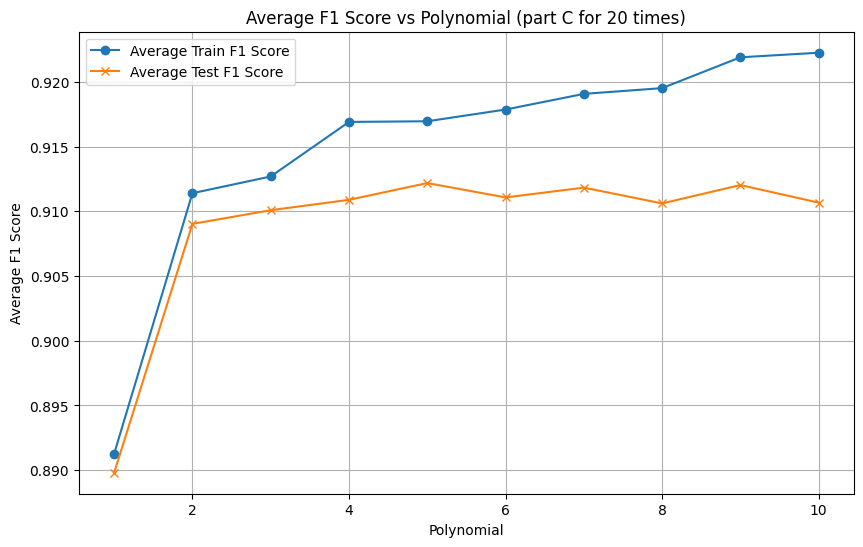

In [ ]:
 # COMP4434 asm2 Problem 2 part c

import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

data = np.loadtxt('problem2data.txt')
X = data[:, :-1]
y = data[:, -1].astype(int)

# Store F1 scores for each degree and then repeat
degrees = range(1, 11)
num_repetitions = 20
train_f1_scores = {degree: [] for degree in degrees}
test_f1_scores = {degree: [] for degree in degrees}

# the repeat loop
for repetition in range(num_repetitions):
    # Iterate over polynomial orders
    for degree in degrees:
        poly = PolynomialFeatures(degree=degree)
        X_poly = poly.fit_transform(X)

        # we want different data splits being used every repetition
        kf = KFold(n_splits=5, shuffle=True, random_state=repetition)

        # Store F1 scores for each loop
        current_train_f1_scores = []
        current_test_f1_scores = []

        for train_index, test_index in kf.split(X_poly):
            X_train, X_test = X_poly[train_index], X_poly[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Better result without ConvergenceWarning at 3000
            model = LogisticRegression(max_iter=3000)

            model.fit(X_train, y_train)

            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            train_f1 = f1_score(y_train, y_train_pred)
            test_f1 = f1_score(y_test, y_test_pred)

            current_train_f1_scores.append(train_f1)
            current_test_f1_scores.append(test_f1)

        # Append average F1 scores for every polynomials (degree)
        train_f1_scores[degree].extend(current_train_f1_scores)
        test_f1_scores[degree].extend(current_test_f1_scores)

# Calculate average F1 scores for every polynomials
avg_train_f1 = [np.mean(train_f1_scores[degree]) for degree in degrees]
avg_test_f1 = [np.mean(test_f1_scores[degree]) for degree in degrees]

plt.figure(figsize=(10, 6))
plt.plot(degrees, avg_train_f1, label='Average Train F1 Score', marker='o')
plt.plot(degrees, avg_test_f1, label='Average Test F1 Score', marker='x')
plt.xlabel('Polynomial')
plt.ylabel('Average F1 Score')
plt.title('Average F1 Score vs Polynomial (part C for 20 times)')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ... (previous code for data points, initial centers, and assignment) ...

# Compute new centroids
new_cluster_centers = []
for cluster_index in range(len(cluster_centers)):  # Iterate through clusters
    cluster_points = data_points[cluster_assignments == cluster_index]  # Get points in the cluster
    new_centroid = np.mean(cluster_points, axis=0)  # Calculate the mean
    new_cluster_centers.append(new_centroid)

new_cluster_centers = np.array(new_cluster_centers)  # Convert to NumPy array

# Print new centroids
print("New Centroids:")
for i, centroid in enumerate(new_cluster_centers):
    print(f"Cluster {i + 1}: {centroid}")

# Data points
data_points = np.array([
    [1.2, 0.5],
    [0.5, 2.4],
    [3, 1.5],
    [2, 3.1],
    [0.5, 3.2],
    [1.6, 4.5]
])

# Initial cluster centers
cluster_centers = np.array([
    [1.2, 0.5],  # Cluster 1 center (1st data point)
    [3, 1.5]    # Cluster 2 center (3rd data point)
])

# Assignment step (one iteration)
cluster_assignments = np.zeros(len(data_points), dtype=int)  # Initialize cluster assignments

for i, point in enumerate(data_points):
    distances = np.linalg.norm(point - cluster_centers, axis=1)  # Calculate distances to centers
    cluster_assignments[i] = np.argmin(distances)  # Assign to nearest cluster

# Plotting
plt.figure(figsize=(6, 6))

# Plot data points with different colors for each cluster
plt.scatter(data_points[cluster_assignments == 0, 0], data_points[cluster_assignments == 0, 1],
            marker='o', color='blue', label='Cluster 1')
plt.scatter(data_points[cluster_assignments == 1, 0], data_points[cluster_assignments == 1, 1],
            marker='o', color='red', label='Cluster 2')

# Plot initial cluster centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='x', color='black', s=100, label='Initial Centers')

# Plot and label new centroids
for i, centroid in enumerate(new_cluster_centers):
    plt.scatter(centroid[0], centroid[1], marker='s', color='green', s=100, label='New Centroids')
    plt.text(centroid[0], centroid[1], f'New Center {i + 1}', ha='center', va='center')  # Label new center

# Add labels and title
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("K-means Classification (One Iteration)")
plt.legend()

# Display the plot
plt.show()

NameError: name 'cluster_centers' is not defined

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split

# Load the dataset
data = np.loadtxt('problem2data.txt')

# Assuming the last column is the target variable and the rest are features
X = data[:, :-1]  # Features (all rows, all columns except the last)
y = data[:, -1]   # Target variable (all rows, last column)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the datasets to confirm
print(f'Train features shape: {X_train.shape}')
print(f'Test features shape: {X_test.shape}')
print(f'Train labels shape: {y_train.shape}')
print(f'Test labels shape: {y_test.shape}')

Train features shape: (800, 3)
Test features shape: (200, 3)
Train labels shape: (800,)
Test labels shape: (200,)


In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
data = np.loadtxt('problem2data.txt')
X = data[:, :-1]  # Features
y = data[:, -1]   # Target variable

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))  # Input layer
model.add(Dense(32, activation='relu'))  # Hidden layer
model.add(Dense(1, activation='sigmoid'))  # Output layer (binary classification)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print(f'Test Accuracy: {accuracy}')

# Classification report for detailed metrics
print(classification_report(y_test, y_pred_classes))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5385 - loss: 0.6639 - val_accuracy: 0.9125 - val_loss: 0.5003
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8601 - loss: 0.5069 - val_accuracy: 0.9125 - val_loss: 0.3541
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8874 - loss: 0.3699 - val_accuracy: 0.9125 - val_loss: 0.2743
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8739 - loss: 0.3556 - val_accuracy: 0.9062 - val_loss: 0.2447
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8862 - loss: 0.2945 - val_accuracy: 0.9062 - val_loss: 0.2311
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8855 - loss: 0.2847 - val_accuracy: 0.9062 - val_loss: 0.2249
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8909 - loss: 0.2898 - val_accuracy: 0.9125 - val_loss: 0.2245
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9089 - loss: 0.2630 - val_accuracy: 0.9125 - val_los

In [11]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import accuracy_score, classification_report

# Reshape your data for CNN (if applicable, e.g., for image data)
# This assumes X_train and X_test are reshaped to (num_samples, height, width, channels)
# For demonstration, I'll use a 28x28 image with 1 channel (grayscale)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)  # Adjust dimensions as needed
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# Define the CNN model
cnn_model = Sequential()
cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))  # For binary classification

# Compile and train the CNN model
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_cnn, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the CNN model
y_pred_cnn = cnn_model.predict(X_test_cnn)
y_pred_classes_cnn = (y_pred_cnn > 0.5).astype(int)

# Calculate and print the performance metrics
cnn_accuracy = accuracy_score(y_test, y_pred_classes_cnn)
print(f'Cnn Test Accuracy: {cnn_accuracy}')
print(classification_report(y_test, y_pred_classes_cnn))

ValueError: cannot reshape array of size 2400 into shape (28,28,1)

In [1]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from sklearn.metrics import accuracy_score, classification_report

# Reshape your data for RNN (e.g., for time series data)
# For demonstration, I'll use a sequence length of 10
X_train_rnn = X_train.reshape(-1, 10, 3)  # Adjust dimensions as needed
X_test_rnn = X_test.reshape(-1, 10, 3)

# Define the RNN model
rnn_model = Sequential()
rnn_model.add(SimpleRNN(50, input_shape=(10, 3), return_sequences=False))
rnn_model.add(Dense(1, activation='sigmoid'))  # For binary classification

# Compile and train the RNN model
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.fit(X_train_rnn, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the RNN model
y_pred_rnn = rnn_model.predict(X_test_rnn)
y_pred_classes_rnn = (y_pred_rnn > 0.5).astype(int)

# Calculate and print the performance metrics
rnn_accuracy = accuracy_score(y_test, y_pred_classes_rnn)
print(f'RNN Test Accuracy: {rnn_accuracy}')
print(classification_report(y_test, y_pred_classes_rnn))

NameError: name 'X_train' is not defined

In [2]:
from keras.models import Sequential
from keras.layers import Dense, Reshape, Flatten, Dropout
from keras.optimizers import Adam

# Define generator
def build_generator():
    model = Sequential()
    model.add(Dense(256, activation='relu', input_dim=100))
    model.add(Reshape((16, 16, 1)))  # Adjust based on desired output size
    return model

# Define discriminator
def build_discriminator():
    model = Sequential()
    model.add(Flatten(input_shape=(16, 16, 1)))  # Adjust based on input shape
    model.add(Dense(1, activation='sigmoid'))
    return model

# Compile models and set up training process
# (Further implementation would include connecting the generator and discriminator)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Step 1: Data Preparation
# Assume you have a dataset of images and their corresponding text descriptions
# images: numpy array of shape (num_samples, height, width, channels)
# texts: list of strings corresponding to the images

# Example image data generator
data_gen = ImageDataGenerator(rescale=1./255)
image_data = data_gen.flow_from_directory('path/to/images', target_size=(64, 64), class_mode='categorical')

# Text preparation
texts = ["A cat sitting on a sofa", "A dog playing in the park"]  # Example descriptions
tokenizer = Tokenizer(num_words=1000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
max_length = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_length)

# Step 2: Model Training (CNN and RNN)
# CNN Model for Image Feature Extraction
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu')
])
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# RNN Model for Text Input
rnn_model = models.Sequential([
    layers.Embedding(input_dim=1000, output_dim=64, input_length=max_length),
    layers.LSTM(64),
    layers.Dense(128, activation='relu')
])
rnn_model.compile(optimizer='adam', loss='mse')

# Step 3: User Input Handling
def generate_image_from_text(user_input):
    # Process user input
    input_seq = tokenizer.texts_to_sequences([user_input])
    padded_input = pad_sequences(input_seq, maxlen=max_length)

    # Get features from RNN
    text_features = rnn_model.predict(padded_input)

    # Here you would typically pass these features to a GAN or similar model
    # For simplicity, let's assume you have a GAN model defined and trained
    generated_image = gan_model.generate(text_features)  # Placeholder for GAN generation
    return generated_image

# Step 4: Image Generation
user_text = "A cat playing with a ball"  # Example user input
generated_image = generate_image_from_text(user_text)

# Display the generated image
import matplotlib.pyplot as plt

plt.imshow(generated_image)
plt.axis('off')
plt.show()